In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/SeoulBikeData (1).csv', encoding='latin1')

In [ ]:
df.shape

(8760, 14)

In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [ ]:
df.duplicated().sum()

np.int64(0)

## **Statistical Summary**

In [ ]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


The Seoul Bike dataset contains 8,760 hourly observations.Bike rental demand ranges from 0 to 3,556 rentals per hour, with an average of approximately 705 rentals.Temperature ranges from -17.8C to 39.4C, while humidity ranges from 0% to 98%. Rainfall and snowfall are zero for most observations, although some periods show considerably higher values.

In [ ]:
df['Seasons'].value_counts()

,count
Seasons,
Spring,2208
Summer,2208
Autumn,2184
Winter,2160


In [ ]:
df['Holiday'].value_counts()

,count
Holiday,
No Holiday,8328
Holiday,432


In [ ]:
df['Functioning Day'].value_counts()

,count
Functioning Day,
Yes,8465
No,295


### **How is bike rental demand distributed?**

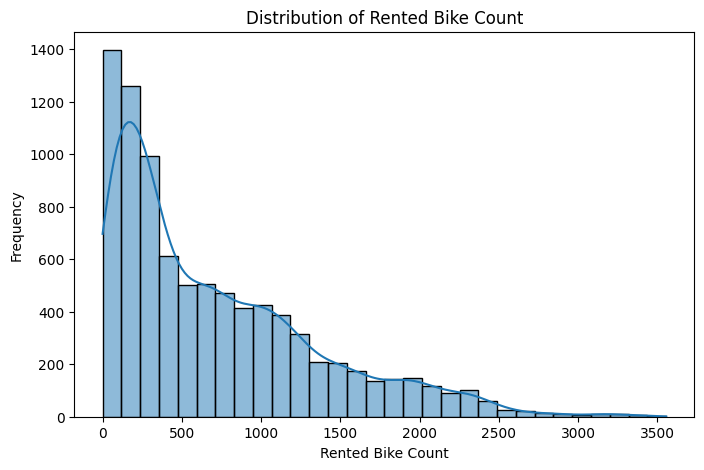

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rented Bike Count'], bins=30, kde=True)

plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')

plt.show()

### ***Rented Bike Count is right-skewed (positively skewed)***

### **Does Temperature Affects Bike Rentals ?**

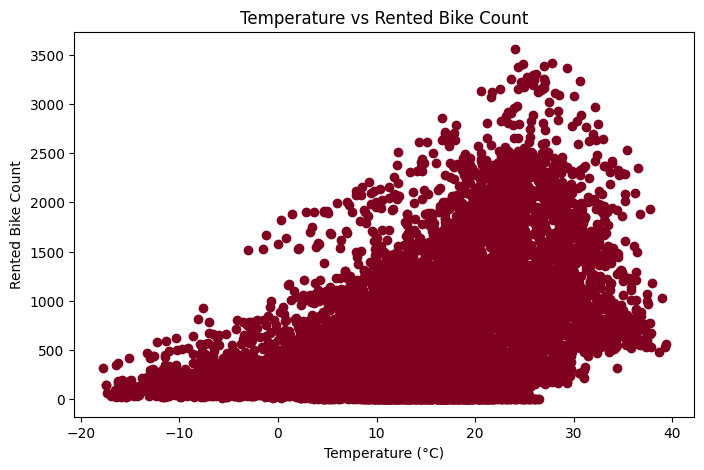

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Temperature(°C)'],
    df['Rented Bike Count'],
    color='#800020'
)

plt.title('Temperature vs Rented Bike Count')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')

plt.show()

### ***As temperature increases, bike rentals generally increase***
 Temperature shows a positive relationship with rented bike count. Higher temperatures are generally associated with higher bike rental demand, although the wide spread of observations indicates that other factors also influence demand.

### **Hour Vs Bike Count**

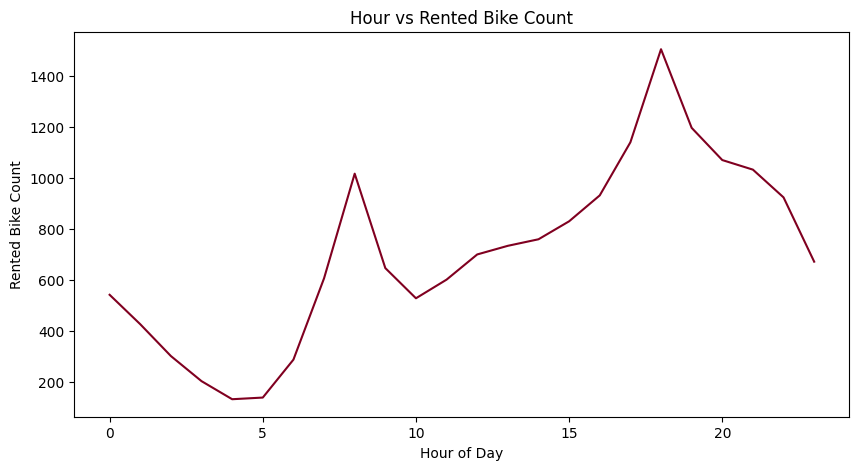

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=df['Hour'],
    y=df['Rented Bike Count'],
    errorbar=None,
    color='#800020'
)

plt.title('Hour vs Rented Bike Count')
plt.xlabel('Hour of Day')
plt.ylabel('Rented Bike Count')

plt.show()

Bike rental demand varies significantly throughout the day. Demand is lowest during the early morning hours, increases sharply around 7–8 AM, and reaches its highest level around 6 PM. After the evening peak, demand gradually decreases.

### **Does bike rental demand change across different seasons?**

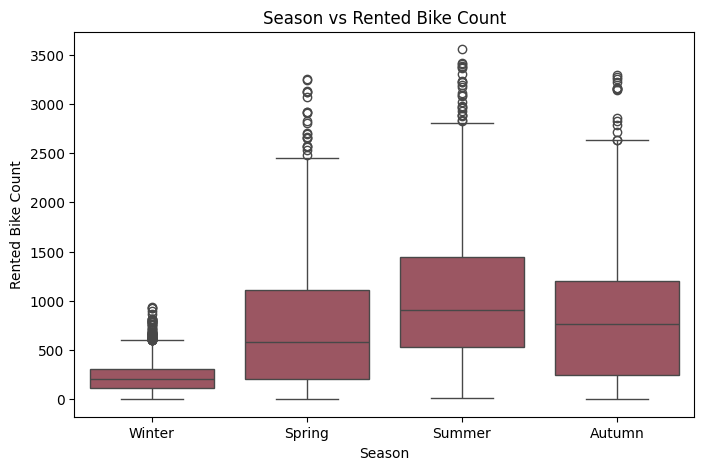

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Seasons',
    y='Rented Bike Count',
    data=df,
    color='#A64B5A'
)

plt.title('Season vs Rented Bike Count')
plt.xlabel('Season')
plt.ylabel('Rented Bike Count')

plt.show()

### **Does bike rental demand change across different seasons?**
Season Vs Bike Rented Demand

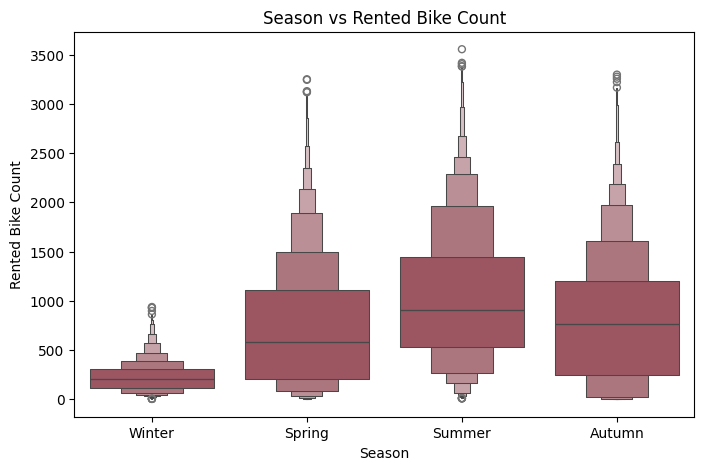

In [ ]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    x='Seasons',
    y='Rented Bike Count',
    data=df,
    color='#A64B5A'
)

plt.title('Season vs Rented Bike Count')
plt.xlabel('Season')
plt.ylabel('Rented Bike Count')

plt.show()

Yes, bike rental demand changes across seasons. Rental demand is generally higher during warmer seasons such as summer and autumn, while winter tends to have lower demand.

### **Is the average rental count higher when the system is functioning?**
Functioning Day Vs Rented Bike Count

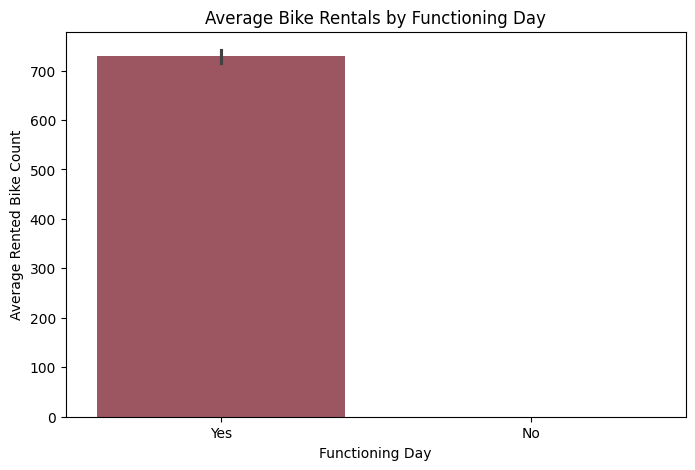

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Functioning Day',
    y='Rented Bike Count',
    data=df,
    estimator='mean',
    color='#A64B5A'
)

plt.title('Average Bike Rentals by Functioning Day')
plt.xlabel('Functioning Day')
plt.ylabel('Average Rented Bike Count')

plt.show()

### **Correlation analysis**

In [ ]:
corr = df.corr(numeric_only=True)

corr

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
Rented Bike Count,1.000000,0.410257,0.538558,-0.199780,0.121108,0.199280,0.379788,0.261837,-0.123074,-0.141804
Hour,0.410257,1.000000,0.124114,-0.241644,0.285197,0.098753,0.003054,0.145131,0.008715,-0.021516
Temperature(°C),0.538558,0.124114,1.000000,0.159371,-0.036252,0.034794,0.912798,0.353505,0.050282,-0.218405
Humidity(%),-0.199780,-0.241644,0.159371,1.000000,-0.336683,-0.543090,0.536894,-0.461919,0.236397,0.108183
Wind speed (m/s),0.121108,0.285197,-0.036252,-0.336683,1.000000,0.171507,-0.176486,0.332274,-0.019674,-0.003554
Visibility (10m),0.199280,0.098753,0.034794,-0.543090,0.171507,1.000000,-0.176630,0.149738,-0.167629,-0.121695
Dew point temperature(°C),0.379788,0.003054,0.912798,0.536894,-0.176486,-0.176630,1.000000,0.094381,0.125597,-0.150887
Solar Radiation (MJ/m2),0.261837,0.145131,0.353505,-0.461919,0.332274,0.149738,0.094381,1.000000,-0.074290,-0.072301
Rainfall(mm),-0.123074,0.008715,0.050282,0.236397,-0.019674,-0.167629,0.125597,-0.074290,1.000000,0.008500
Snowfall (cm),-0.141804,-0.021516,-0.218405,0.108183,-0.003554,-0.121695,-0.150887,-0.072301,0.008500,1.000000


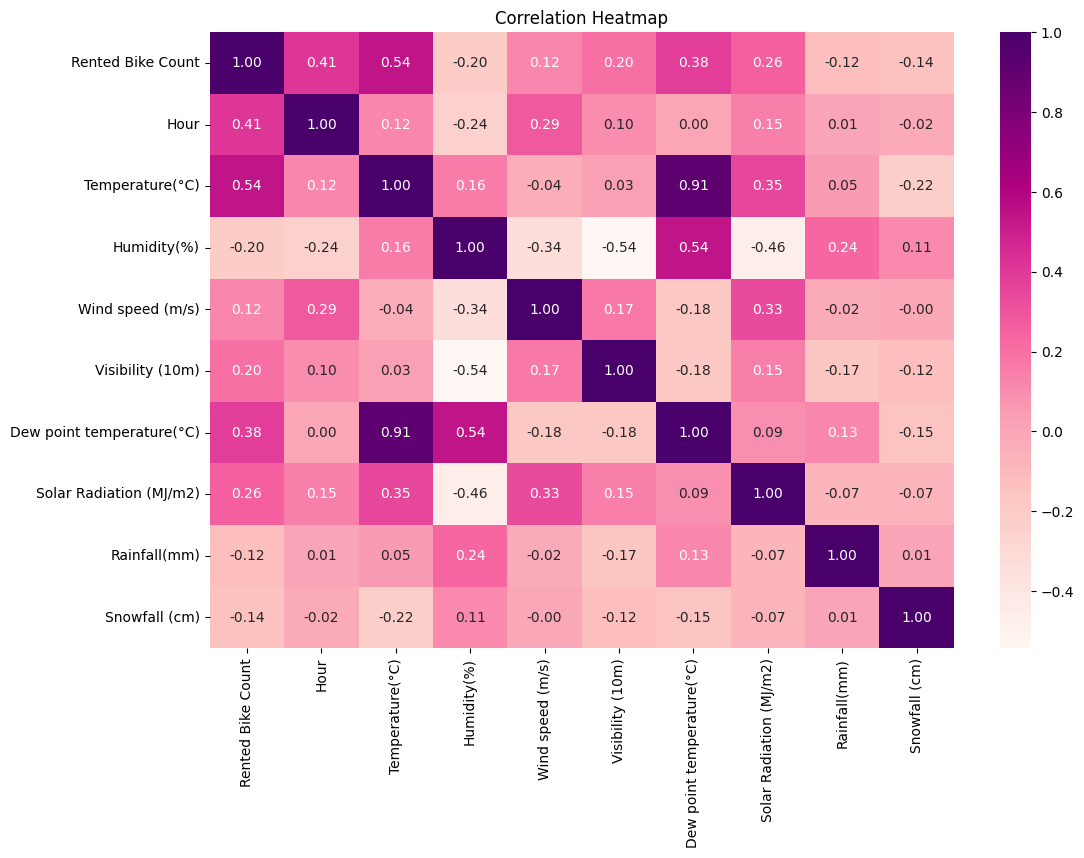

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdPu',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
print(df['Seasons'].unique())
print(df['Holiday'].unique())
print(df['Functioning Day'].unique())

['Winter' 'Spring' 'Summer' 'Autumn']
['No Holiday' 'Holiday']
['Yes' 'No']


In [ ]:
df = pd.get_dummies(
    df,
    columns=['Seasons'],
    drop_first=True
)

In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,False,False,True
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,False,False,True
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,No Holiday,Yes,False,False,True
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,No Holiday,Yes,False,False,True
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,No Holiday,Yes,False,False,True


In [ ]:
drop_first=True

In [ ]:
df['Holiday'] = df['Holiday'].map({
    'No Holiday': 0,
    'Holiday': 1
})

df['Functioning Day'] = df['Functioning Day'].map({
    'No': 0,
    'Yes': 1
})

In [ ]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,1,False,False,True
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,1,False,False,True


### **Regression**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df.drop('Date', axis=1, inplace=True)

In [ ]:
df.columns

Index(['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday',
       'Functioning Day', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Year', 'Month', 'Day'],
      dtype='object')

In [ ]:
y = df['Rented Bike Count']

In [ ]:
X = df.drop('Rented Bike Count', axis=1)

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8760, 17)
y shape: (8760,)


In [ ]:
X.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Seasons_Spring,Seasons_Summer,Seasons_Winter,Year,Month,Day
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True,2017,12,1
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True,2017,12,1
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,1,False,False,True,2017,12,1
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True,2017,12,1
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,1,False,False,True,2017,12,1


### **Train - Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7008, 17)
X_test: (1752, 17)
y_train: (7008,)
y_test: (1752,)


### **Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
Model=LinearRegression()

In [ ]:
Model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = Model.predict(X_test)

In [ ]:
print(y_pred[:10])

[ 911.30133218 1138.8121803  1321.89753424 1335.71756292  549.90078204
  782.62048464 1451.7706161  1035.38159021  912.36766746  860.5185748 ]


### **Model Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 330.6065359813694
MSE: 194032.08402520936
RMSE: 440.4907309186078
R² Score: 0.5343001653095691


### **Decision Tree Regression**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt_Model=DecisionTreeRegressor(random_state=42)

In [ ]:
dt_Model.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt_pred=dt_Model.predict(X_test)

### **Decision Tree Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree MSE:", dt_mse)
print("Decision Tree RMSE:", dt_rmse)
print("Decision Tree R² Score:", dt_r2)

Decision Tree MAE: 179.22374429223746
Decision Tree MSE: 105013.87214611872
Decision Tree RMSE: 324.0584393996224
Decision Tree R² Score: 0.7479543491771412


### **Random Forest Regression - Ensemble Technique**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_Model= RandomForestRegressor(n_estimators=100,random_state=42)

In [ ]:
rf_Model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred=rf_Model.predict(X_test)


### **Random Forest Evaluation**

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 136.10937785388128
Random Forest MSE: 52131.00136489725
Random Forest RMSE: 228.3221438338762
Random Forest R² Score: 0.8748794621268663


### **Model Comparison**

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae, dt_mae, rf_mae],
    'RMSE': [rmse, dt_rmse, rf_rmse],
    'R² Score': [r2, dt_r2, rf_r2]})
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,330.606536,440.490731,0.534300
1,Decision Tree,179.223744,324.058439,0.747954
2,Random Forest,136.109378,228.322144,0.874879


### **K-Means Clustering**

In [ ]:
cluster_data = df[[
        'Temperature(°C)',
        'Humidity(%)',
        'Wind speed (m/s)',
        'Visibility (10m)',
        'Solar Radiation (MJ/m2)',
        'Rainfall(mm)',
        'Snowfall (cm)',
        'Rented Bike Count']]

In [ ]:
cluster_data.head()

,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
0,-5.2,37,2.2,2000,0.0,0.0,0.0,254
1,-5.5,38,0.8,2000,0.0,0.0,0.0,204
2,-6.0,39,1.0,2000,0.0,0.0,0.0,173
3,-6.2,40,0.9,2000,0.0,0.0,0.0,107
4,-6.0,36,2.3,2000,0.0,0.0,0.0,78


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

### **Elbow Method**

In [ ]:
cluster_data = df[[
        'Temperature(°C)',
        'Humidity(%)',
        'Wind speed (m/s)',
        'Visibility (10m)',
        'Solar Radiation (MJ/m2)',
        'Rainfall(mm)',
        'Snowfall (cm)',
        'Rented Bike Count']]
cluster_data.head()

,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
0,-5.2,37,2.2,2000,0.0,0.0,0.0,254
1,-5.5,38,0.8,2000,0.0,0.0,0.0,204
2,-6.0,39,1.0,2000,0.0,0.0,0.0,173
3,-6.2,40,0.9,2000,0.0,0.0,0.0,107
4,-6.0,36,2.3,2000,0.0,0.0,0.0,78


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

In [ ]:
cluster_scaled[:5]

array([[-1.51395724, -1.04248288,  0.45847578,  0.92587135, -0.65513172,
        -0.13179988, -0.17189109, -0.69865046],
       [-1.53907415, -0.99336999, -0.8925615 ,  0.92587135, -0.65513172,
        -0.13179988, -0.17189109, -0.77617457],
       [-1.58093567, -0.94425709, -0.69955617,  0.92587135, -0.65513172,
        -0.13179988, -0.17189109, -0.82423951],
       [-1.59768028, -0.8951442 , -0.79605883,  0.92587135, -0.65513172,
        -0.13179988, -0.17189109, -0.92657134],
       [-1.58093567, -1.09159578,  0.55497844,  0.92587135, -0.65513172,
        -0.13179988, -0.17189109, -0.97153532]])

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

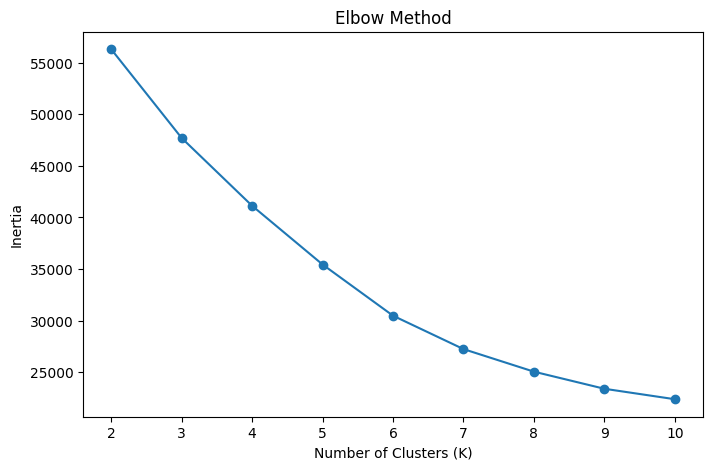

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(cluster_scaled)

print(kmeans_labels[:20])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
cluster_data['KMeans_Cluster'] = kmeans_labels

cluster_data.head()

/tmp/ipykernel_674/2961707240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['KMeans_Cluster'] = kmeans_labels


,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count,KMeans_Cluster
0,-5.2,37,2.2,2000,0.0,0.0,0.0,254,2
1,-5.5,38,0.8,2000,0.0,0.0,0.0,204,2
2,-6.0,39,1.0,2000,0.0,0.0,0.0,173,2
3,-6.2,40,0.9,2000,0.0,0.0,0.0,107,2
4,-6.0,36,2.3,2000,0.0,0.0,0.0,78,2


In [ ]:
cluster_data['KMeans_Cluster'].value_counts().sort_index()

,count
KMeans_Cluster,
0,2822
1,3258
2,2513
3,167


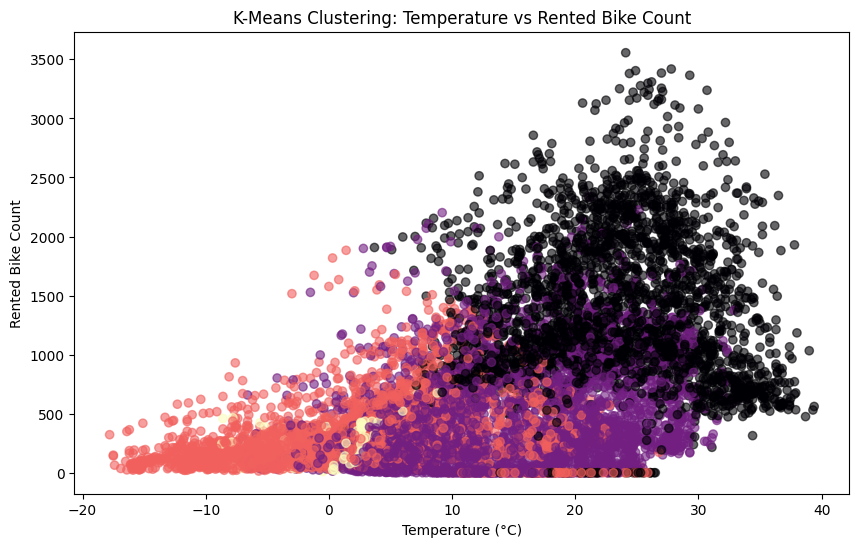

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data['Temperature(°C)'],
    cluster_data['Rented Bike Count'],
    c=cluster_data['KMeans_Cluster'],
    cmap='magma',
    alpha=0.6
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')
plt.title('K-Means Clustering: Temperature vs Rented Bike Count')

plt.show()

K-Means clustering identified four groups of observations based on similarities in weather conditions and bike rental demand. The clusters show that bike rental demand generally increases with temperature, although some overlap exists between the groups.

## **DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=10)

dbscan_labels = dbscan.fit_predict(cluster_scaled)

print(dbscan_labels[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 9 0 0 0]


In [ ]:
cluster_data['DBSCAN_Cluster'] = dbscan_labels

cluster_data.head()

/tmp/ipykernel_674/4045025066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['DBSCAN_Cluster'] = dbscan_labels


,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count,KMeans_Cluster,DBSCAN_Cluster
0,-5.2,37,2.2,2000,0.0,0.0,0.0,254,2,0
1,-5.5,38,0.8,2000,0.0,0.0,0.0,204,2,0
2,-6.0,39,1.0,2000,0.0,0.0,0.0,173,2,0
3,-6.2,40,0.9,2000,0.0,0.0,0.0,107,2,0
4,-6.0,36,2.3,2000,0.0,0.0,0.0,78,2,0


In [ ]:
cluster_data['DBSCAN_Cluster'].value_counts().sort_index()

,count
DBSCAN_Cluster,
-1,959
0,7648
1,16
2,20
3,13
4,11
5,16
6,16
7,14


### **DBSCAN visualization**

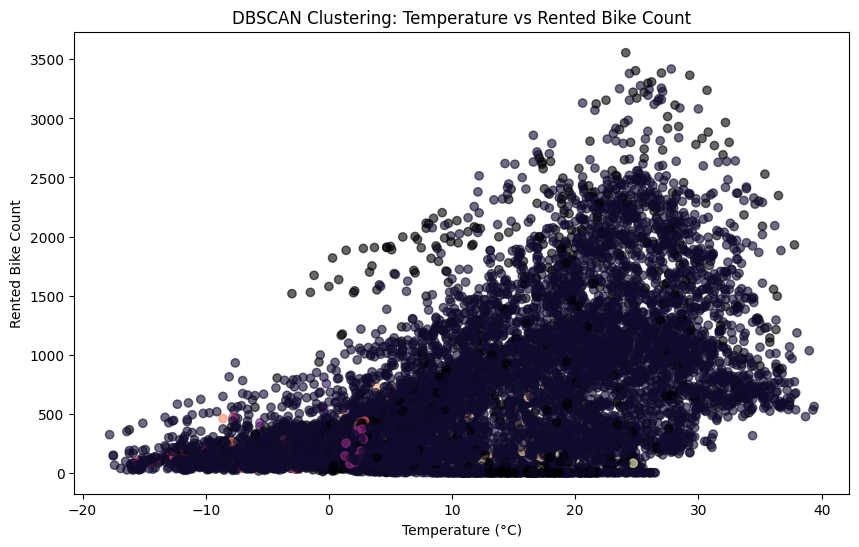

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cluster_data['Temperature(°C)'],
    cluster_data['Rented Bike Count'],
    c=cluster_data['DBSCAN_Cluster'],
    cmap='magma',
    alpha=0.6
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')
plt.title('DBSCAN Clustering: Temperature vs Rented Bike Count')

plt.show()

### **Model Comparison**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [330.606536, 179.223744, 136.109378],
    'RMSE': [440.490731, 324.058439, 228.322144],
    'R² Score': [0.534300, 0.747954, 0.874879]
})

model_results

,Model,MAE,RMSE,R² Score
0,Linear Regression,330.606536,440.490731,0.534300
1,Decision Tree,179.223744,324.058439,0.747954
2,Random Forest,136.109378,228.322144,0.874879


### **Model Performance Comparison**

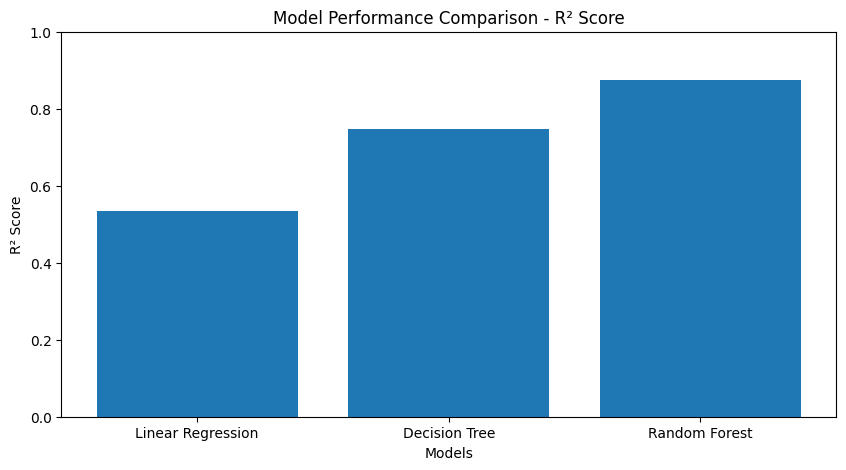

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(model_results['Model'], model_results['R² Score'])

plt.xlabel('Models')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison - R² Score')

plt.ylim(0, 1)
plt.show()

## **Final Project Conclusion**

### Key Insights

- Bike rental demand varies with time, weather, and seasonal conditions.
- Temperature shows a positive relationship with bike rental demand.
- K-Means identified distinct groups based on weather conditions and rental patterns.
- DBSCAN identified dense groups and outlier observations in the data.
- Regression models were used to predict bike rental demand.
- Random Forest achieved the highest R² score among the tested models.
- The project demonstrates how EDA and Machine Learning can be used to understand and predict bike rental demand.

### **Project Summary**

This project analyzed the Seoul Bike Sharing Demand dataset using Exploratory Data Analysis, K-Means Clustering, DBSCAN, and Regression techniques. Different regression models were evaluated using MAE, RMSE, and R² Score to understand their predictive performance.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Seoul Pic.png to Seoul Pic (1).png


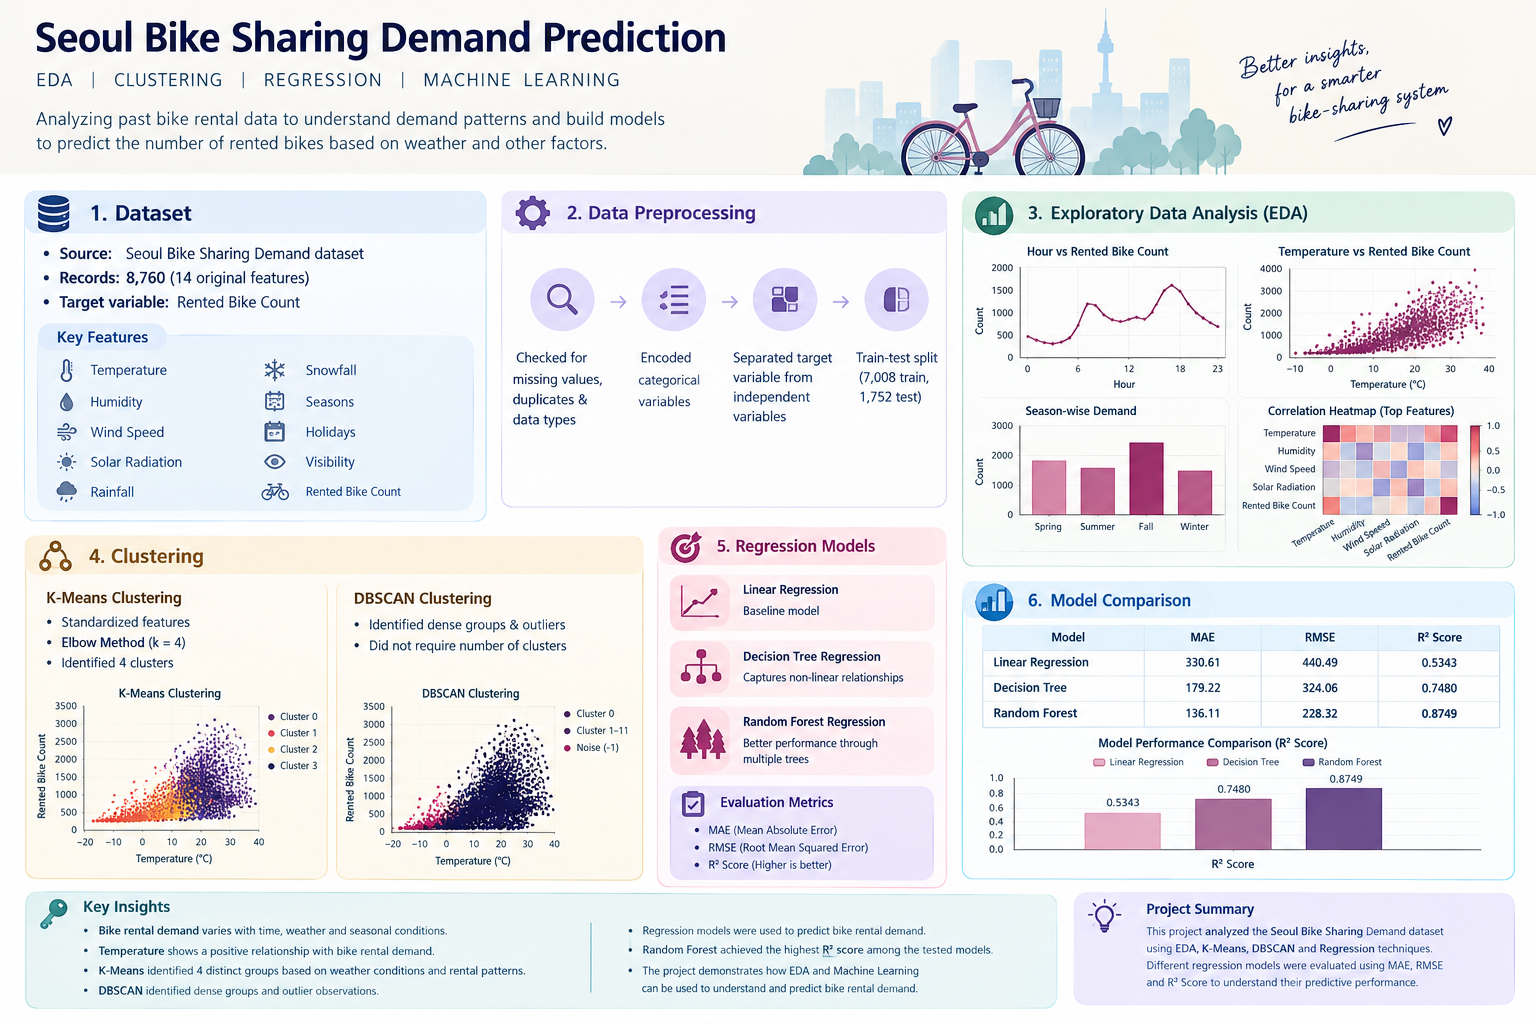

In [ ]:
from IPython.display import Image, display

display(Image(filename='/content/Seoul Pic (1).png', width=800))